Kent Lin Chan

20202132

Se usó python 3.14.2

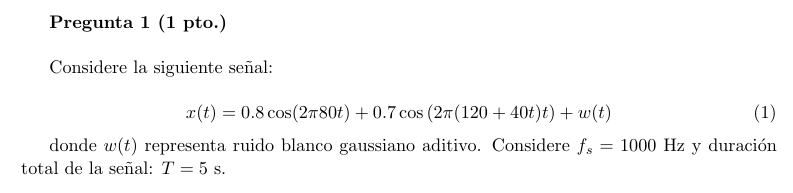

In [21]:
import matplotlib.pyplot as plt
import numpy as np

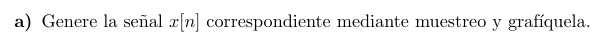

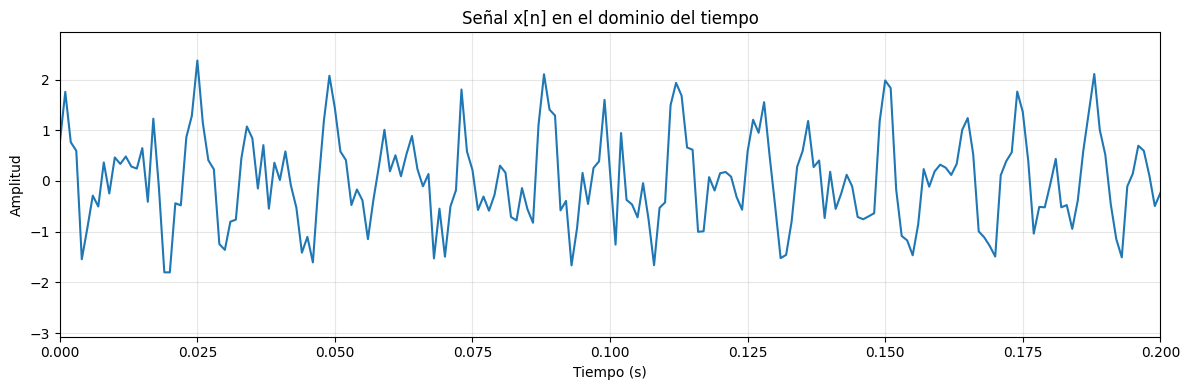

In [22]:
fs = 1000
T = 5
N = fs * T

t = np.arange(N) / fs

chirp = 120 + 40 * t

x = 0.8 * np.cos(2 * np.pi * 80 * t) + 0.7 * np.cos(2 * np.pi * chirp * t)

# Agregar ruido blanco gaussiano
w = np.random.normal(0, 0.5, x.shape)

x = x + w

plt.figure(figsize=(12, 4))
plt.plot(t, x, linewidth=1.5)
plt.title('Señal x[n] en el dominio del tiempo')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True, alpha=0.3)
plt.xlim(0, 0.2)
plt.tight_layout()
plt.show()

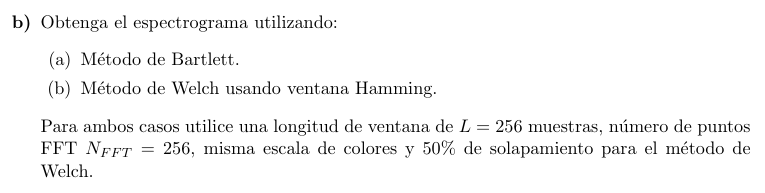

In [23]:
L = 256
Nfft = 256
solapamiento = int(L* 0.5)

In [24]:
def espectrograma_bartlett(x, L, Nfft):
    M = len(x) // L
    Xper = np.zeros([M, Nfft])
    for m in range(M):
        xm = x[m*L:(m+1)*L]
        Xper[m, :] = np.abs(np.fft.fft(xm, Nfft))**2 / L
    Xper = np.fft.fftshift(Xper, axes=1)
    return Xper, (np.arange(Nfft) - Nfft/2) * fs / Nfft, np.arange(M) * L / fs

def espectrograma_welch(x, L, Nfft, ventana, solapamiento):
    paso = L - solapamiento
    M = (len(x) - L) // paso + 1
    Xper = np.zeros([M, Nfft])
    for m in range(M):
        inicio = m * paso
        xm = ventana * x[inicio:inicio+L]
        Xper[m, :] = np.abs(np.fft.fft(xm, Nfft))**2 / L
    Xper = np.fft.fftshift(Xper, axes=1)
    return Xper, (np.arange(Nfft) - Nfft/2) * fs / Nfft, np.arange(M) * paso / fs

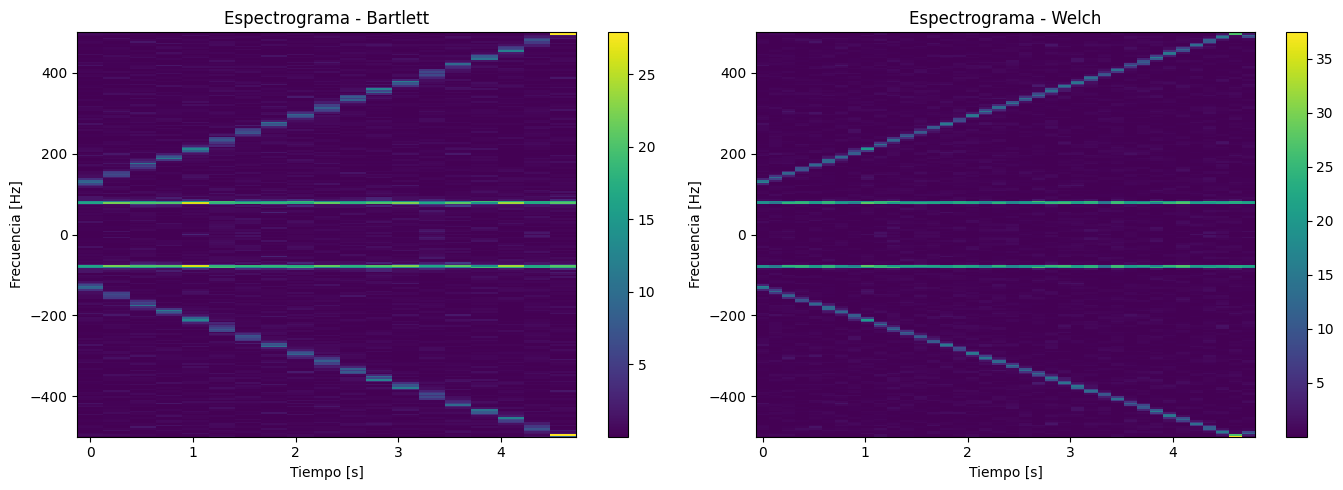

In [25]:
hamming = np.hamming(L)
hamming = hamming / np.sqrt(np.mean(np.abs(hamming)**2))

X_bart, fk, tm = espectrograma_bartlett(x, L, Nfft)
X_welch, fk_w, tm_w = espectrograma_welch(x, L, Nfft, hamming, solapamiento)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
c1 = plt.pcolormesh(tm, fk, np.abs(X_bart.T), shading='auto')
plt.title('Espectrograma - Bartlett')
plt.xlabel('Tiempo [s]')
plt.ylabel('Frecuencia [Hz]')
plt.ylim(-fs/2, fs/2)
plt.colorbar(c1)

plt.subplot(1, 2, 2)
c2 = plt.pcolormesh(tm_w, fk_w, np.abs(X_welch.T), shading='auto')
plt.title('Espectrograma - Welch')
plt.xlabel('Tiempo [s]')
plt.ylabel('Frecuencia [Hz]')
plt.ylim(-fs/2, fs/2)
plt.colorbar(c2)

plt.tight_layout()
plt.show()

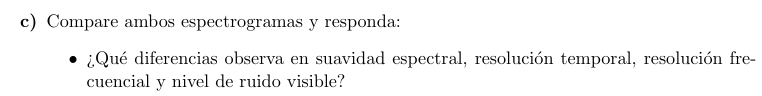

Respecto a la suavidad espectral, el método de Bartlett presenta variabilidad entre ventanas sucesivas debido a que sus segmentos se procesan sin solapamiento. En contraste, Welch produce un espectrograma donde la energía espectral varía de forma más gradual y continua a lo largo del tiempo, sin los saltos abruptos característicos de Bartlett. El solapamiento del 50% es el responsable de esta diferencia, ya que permite transiciones más suaves entre ventanas consecutivas.

En cuanto a la resolución temporal, Bartlett ofrece teóricamente una mejor resolución temporal al no aplicar solapamiento entre segmentos. Esto le permite detectar cambios rápidos en la frecuencia. Sin embargo, visualmente el espectrograma de Bartlett es menos uniforme. Welch, aunque tiene una resolución temporal efectiva menor por el solapamiento, genera un resultado visual más continuo que facilita enormemente el seguimiento de componentes que varían en frecuencia, como es el caso del chirp.

La resolución frecuencial resulta ser similar en ambos métodos porque ambos utilizan FFT con 256 puntos. Sin embargo, el leakage espectral en Welch, las líneas de las componentes de frecuencia fija se ven más nítidas y definidas, mientras que en Bartlett presentan mayor ensanchamiento debido a la dispersión de energía hacia frecuencias vecinas.

El nivel de ruido en Bartlett se observa un fondo con muchos píxeles de color distribuidos aleatoriamente en todo el espectro. En Welch el fondo es notablemente más limpio y oscuro, con mucho menos ruido de fondo visible.

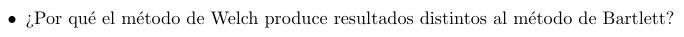

Welch se diferencia de Bartlett por tres razones fundamentales que se hacen evidentes al observar los espectrogramas. Primero, la ventana de Hamming que Welch aplica antes de la FFT reduce drásticamente el leakage espectral, haciendo que las líneas espectrales sean más delgadas y concentradas. Segundo, al avanzar solo 128 muestras en lugar de 256 entre segmentos, Welch genera aproximadamente el doble de ventanas temporales, proporcionando mayor densidad de información en el eje temporal. Esto permite seguir la evolución del chirp de manera más fluida y sin los saltos característicos de Bartlett. Tercero, el solapamiento en Welch introduce un promediado temporal implícito donde cada instante de tiempo es cubierto por múltiples ventanas superpuestas, lo que suaviza naturalmente los cambios abruptos.

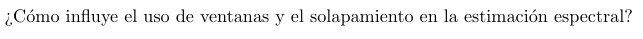

La ventana de Hamming atenúa las discontinuidades en los bordes de cada segmento, eliminando la energía que se dispersa hacia frecuencias adyacentes. Esto se traduce en líneas espectrales más finas y definidas en Welch comparadas con las líneas anchas y difusas de Bartlett. El solapamiento aporta mayor densidad temporal y reduce la varianza de la estimación espectral al proporcionar más realizaciones para promediar. La combinación de ambos factores produce el efecto más notorio: el fondo ruidoso de Bartlett prácticamente desaparece en Welch, dejando un espectrograma donde la señal destaca nítidamente sobre un fondo limpio.

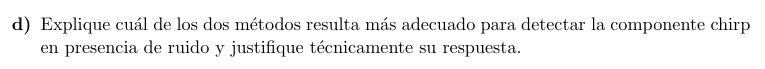

Welch es claramente el método más adecuado para detectar la componente chirp en presencia de ruido, tal como se observa directamente en los espectrogramas generados. La diferencia en claridad de la trayectoria del chirp es notoria: mientras que en Bartlett la línea diagonal aparece como una secuencia de escalones discontinuos que saltan entre posiciones, en Welch esta misma trayectoria se presenta como una línea suave y continua, fácil de identificar visualmente.

Welch ofrece una relación señal-ruido significativamente mejor que Bartlett. Los píxeles de ruido dispersos en Bartlett contrastan con el fondo oscuro y limpio de Welch, donde las componentes del chirp y las frecuencias fijas son claramente visibles. Esta diferencia es particularmente importante al tratar con señales de baja energía o contaminadas por ruido.

Aunque ambos métodos comparten la misma resolución frecuencial teórica, el leakage en Bartlett reduce la resolución práctica. Las líneas anchas y difusas pueden ocultar componentes espectrales cercanos. En Welch, las líneas estrechas y bien definidas permiten resolver mejor los cambios de frecuencia del chirp y separar componentes adyacentes.

Para la detección de chirps en ruido, Welch es la opción recomendada. Produce un espectrograma donde el chirp es significativamente más fácil de detectar, visualizar y analizar. En comparación con Bartlett, aunque teóricamente ofrece mejor resolución temporal, resulta menos útil en la práctica por su mayor ruido de fondo y sus discontinuidades que ocultan la verdadera estructura de la señal.